<a href="https://colab.research.google.com/github/aniilkeles/Machine-Learning-Projects/blob/main/Unsupervised%20Learning/55_UnsupervisedLearningProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [122]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [124]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/29-country_data.csv')

In [125]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [127]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [128]:
import math

def plot_all_histograms(df, title_prefix=""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"{title_prefix}{col}")
        plt.xlabel("")
        plt.ylabel("")

    plt.tight_layout()
    plt.show()

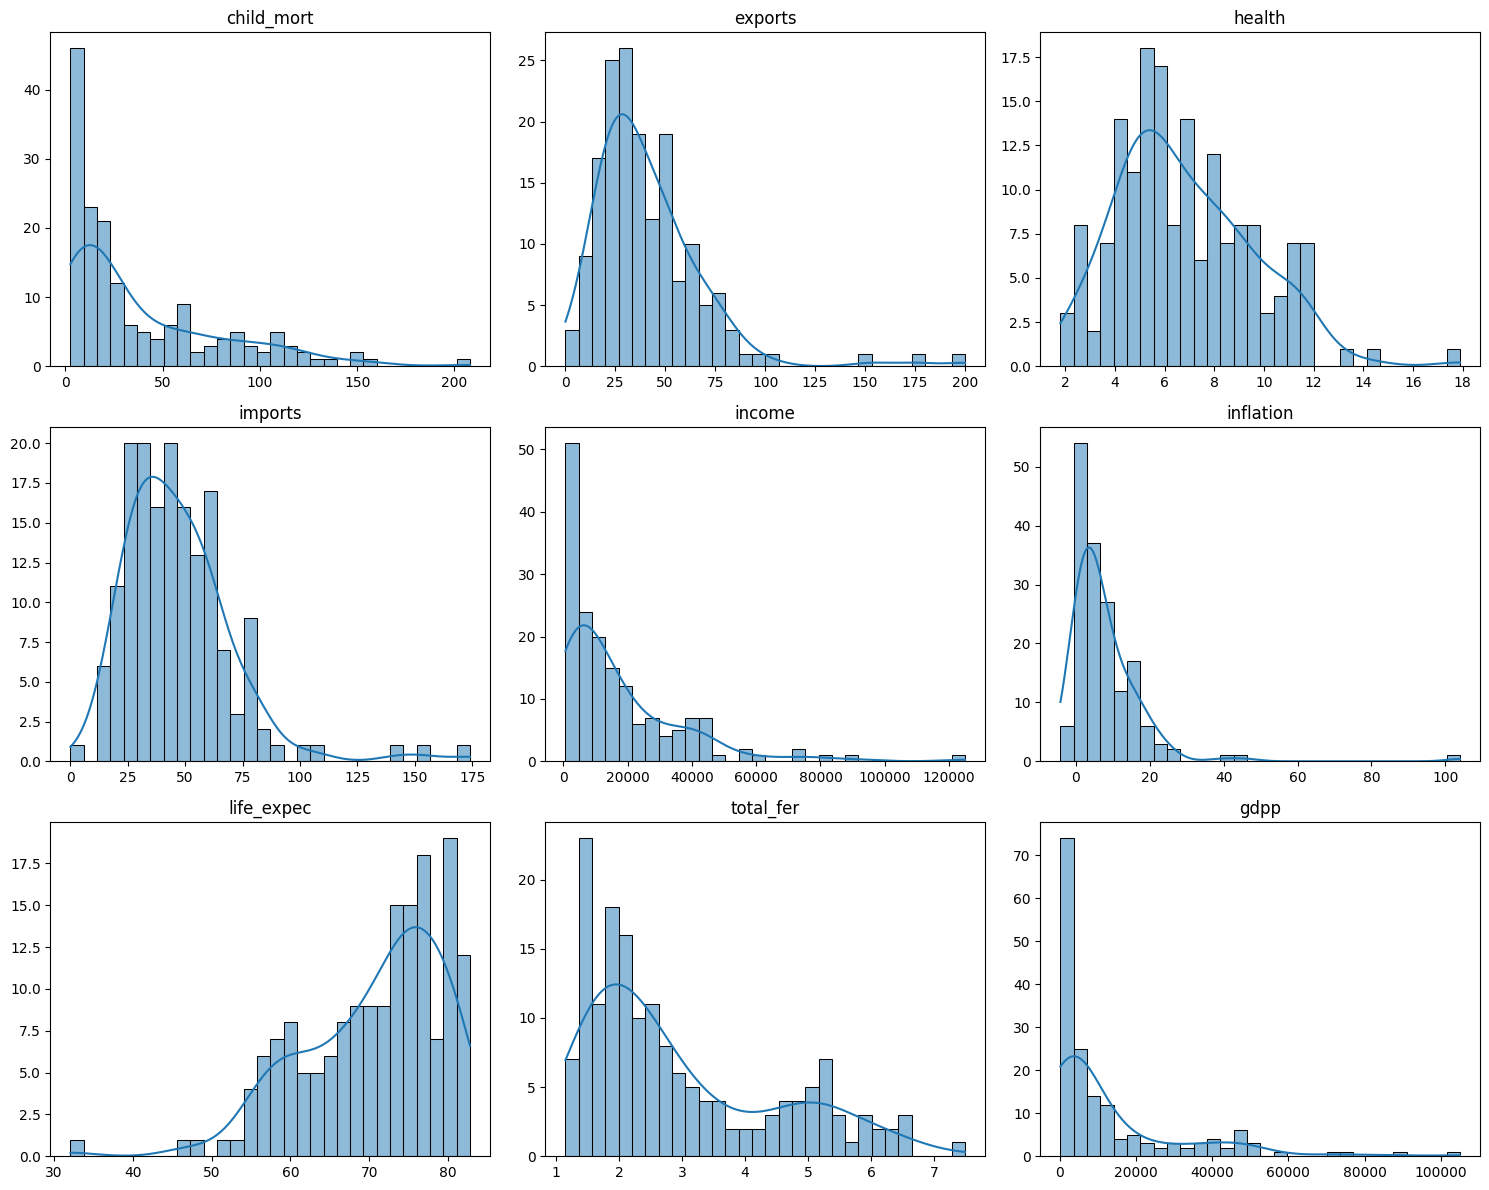

In [129]:
plot_all_histograms(df)

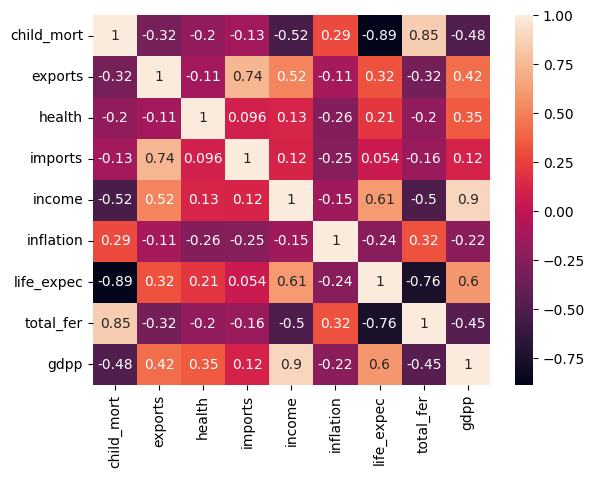

In [130]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [131]:
df_new = df.drop("country",axis=1)

In [132]:
df_new.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [133]:
from sklearn.preprocessing import MinMaxScaler

In [134]:
scaler = MinMaxScaler()

In [135]:
df_new = scaler.fit_transform(df_new)

In [136]:
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

In [137]:
df_new = pd.DataFrame(df_new , columns = ['child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'])

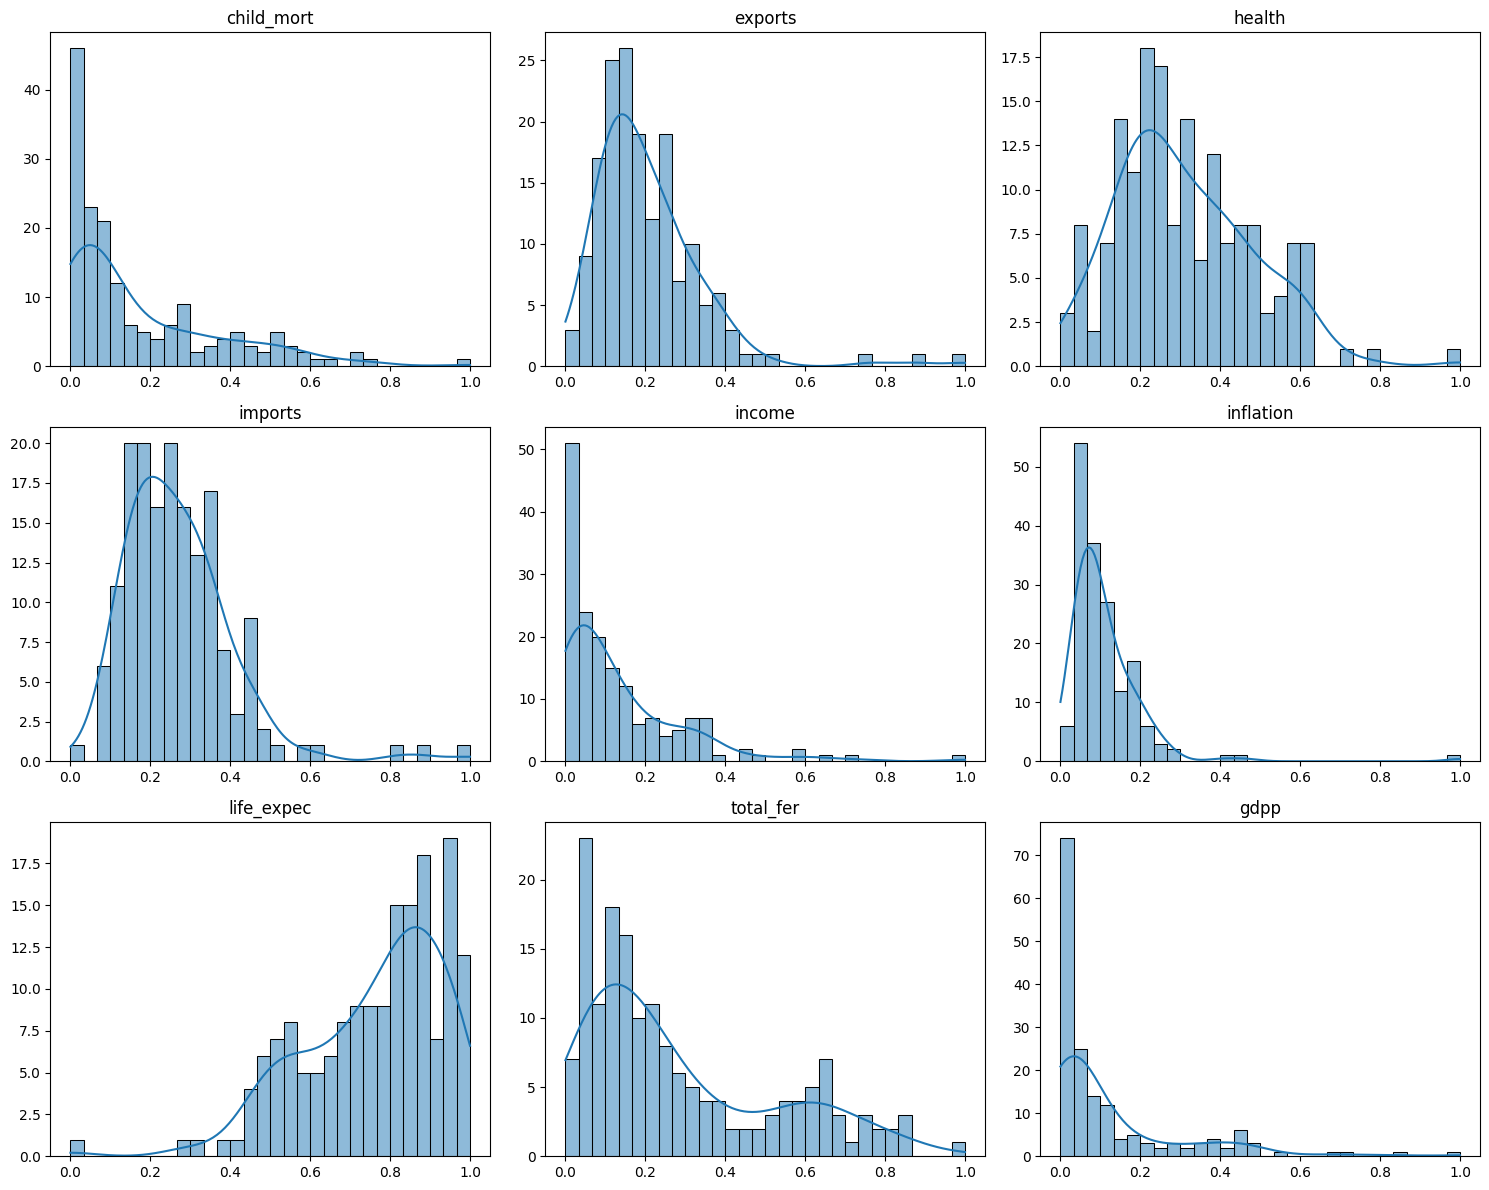

In [138]:
plot_all_histograms(df_new)

In [139]:
# PCA
from sklearn.decomposition import PCA

In [140]:
pca = PCA()

In [141]:
pca_df_new = pd.DataFrame(pca.fit_transform(df_new))

In [142]:
pca_df_new

,0,1,2,3,4,5,6,7,8
0,0.599078,0.095490,0.157554,0.024333,0.045618,-0.046532,-0.076803,-0.040610,0.023572
1,-0.158474,-0.212092,-0.064189,0.061247,-0.014191,-0.010246,0.043567,-0.030842,0.029833
2,-0.003686,-0.135867,-0.134182,-0.133574,0.091150,0.025988,0.045604,0.010198,0.003012
3,0.650235,0.275975,-0.142672,-0.156018,0.081997,0.032170,0.073985,0.045195,-0.042241
4,-0.200711,-0.064662,-0.100715,0.037902,0.035799,-0.055817,0.009559,-0.026228,0.022455
...,...,...,...,...,...,...,...,...,...
162,0.160078,-0.029625,-0.121910,0.066099,0.009043,-0.063646,-0.115254,0.003232,-0.065701
163,-0.061133,-0.171339,-0.058586,-0.247460,0.093260,0.291515,-0.005521,-0.056038,-0.036459
164,-0.115512,-0.032034,-0.195243,0.231993,0.035734,0.089237,0.039743,0.006124,-0.017780
165,0.332968,-0.019824,-0.029989,-0.105416,0.141550,0.063254,-0.012519,-0.014231,-0.011441


In [143]:
pca.explained_variance_

array([0.14180615, 0.03450913, 0.03171502, 0.02513534, 0.00974048,
       0.00776992, 0.00306922, 0.00228894, 0.00178941])

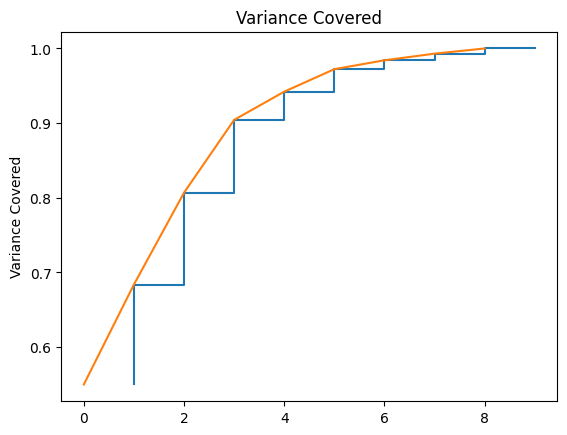

In [144]:
plt.step(list(range(1,10)),np.cumsum(pca.explained_variance_ratio_))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.ylabel("Variance Covered")
plt.title("Variance Covered")
plt.show()

In [145]:
pca_df_new = pca_df_new.drop(columns=[3,4,5,6,7,8])

In [146]:
pca_df_new

,0,1,2
0,0.599078,0.095490,0.157554
1,-0.158474,-0.212092,-0.064189
2,-0.003686,-0.135867,-0.134182
3,0.650235,0.275975,-0.142672
4,-0.200711,-0.064662,-0.100715
...,...,...,...
162,0.160078,-0.029625,-0.121910
163,-0.061133,-0.171339,-0.058586
164,-0.115512,-0.032034,-0.195243
165,0.332968,-0.019824,-0.029989


In [147]:
# Hierarchical Clustering

In [148]:
import scipy.cluster.hierarchy as sch

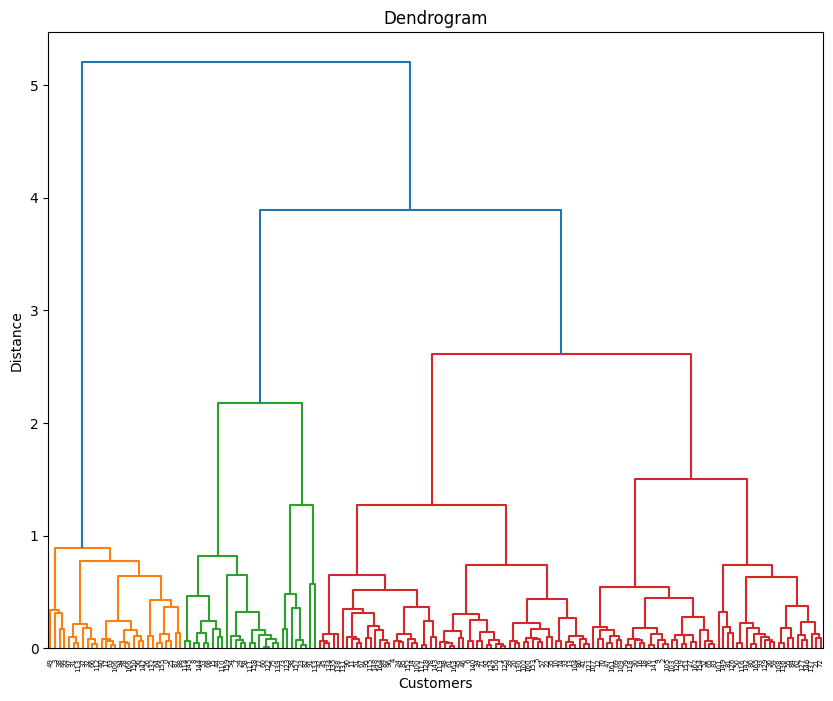

In [149]:
plt.figure(1, figsize = (10,8))
dendrogram = sch.dendrogram(sch.linkage(pca_df_new, method="ward"))
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

In [150]:
# When we look at the dendongram , we can clearly see 3 or 4 cluster is good for our algorithm.

In [151]:
from sklearn.cluster import AgglomerativeClustering

In [152]:
hc = AgglomerativeClustering(n_clusters=3)

In [153]:
y_hc = hc.fit_predict(pca_df_new)

In [154]:
y_hc

array([1, 0, 0, 1, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 0, 2, 0, 1, 0, 0, 0, 0,
       0, 2, 0, 1, 1, 0, 1, 2, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       2, 0, 0, 0, 0, 1, 0, 0, 0, 2, 2, 0, 1, 0, 2, 0, 2, 0, 0, 1, 1, 0,
       1, 0, 2, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1,
       1, 0, 0, 2, 0, 0, 1, 0, 0, 1, 2, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       2, 2, 1, 1, 2, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 2, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 2, 2, 2, 0, 0, 0, 0, 0, 0, 1])

In [155]:
df['cluster'] = y_hc

In [156]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0


In [157]:
df.groupby("cluster").mean(numeric_only=True)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster,,,,,,,,,
0,27.902752,39.043844,6.275688,46.486843,12345.963303,7.721872,71.588073,2.593394,6940.330275
1,110.489655,31.224828,6.505862,44.862069,3119.068966,12.902241,56.724138,5.478621,1473.034483
2,5.017241,58.755172,9.155172,50.434483,49206.896552,2.886793,80.506897,1.750000,47096.551724


In [158]:
pca_df_new["cluster"] = y_hc

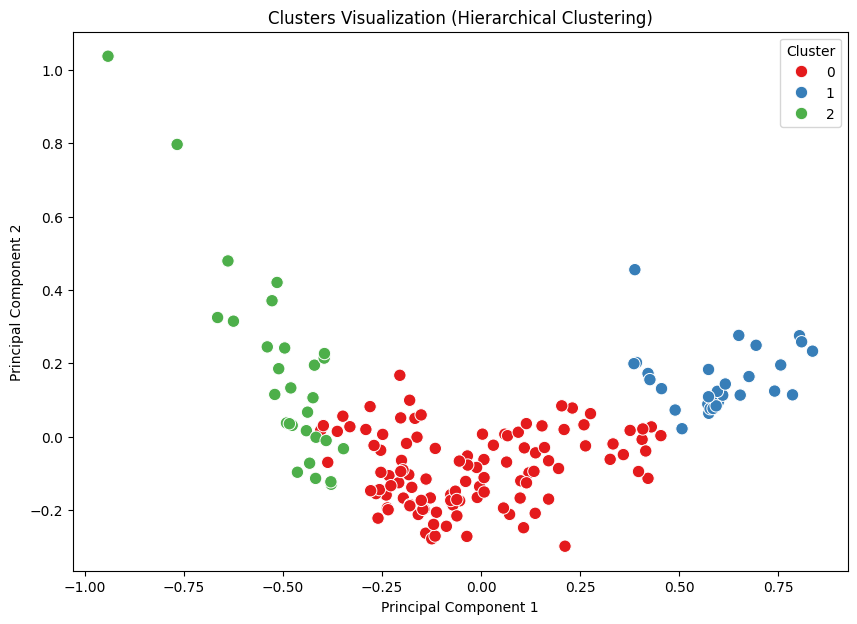

In [159]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x=pca_df_new.iloc[:,0],
    y=pca_df_new.iloc[:,1],
    hue=pca_df_new["cluster"],
    palette="Set1",
    s=80
)

plt.title("Clusters Visualization (Hierarchical Clustering)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

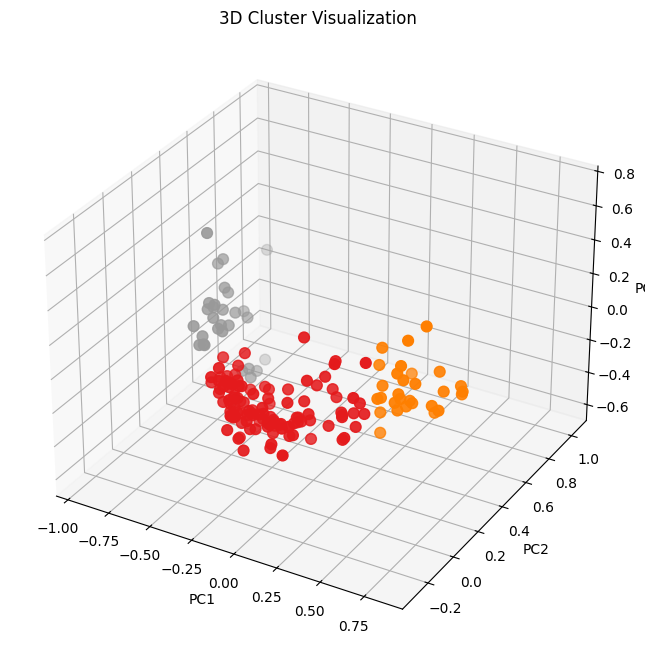

In [160]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    pca_df_new.iloc[:,0],
    pca_df_new.iloc[:,1],
    pca_df_new.iloc[:,2],
    c=pca_df_new["cluster"],
    cmap="Set1",
    s=60
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D Cluster Visualization")
plt.show()

In [161]:
from sklearn.metrics import silhouette_score

In [162]:
print(silhouette_score(pca_df_new,y_hc))

0.7320624525728687


In [163]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

X = pca_df_new.iloc[:, :3].values  # PC1, PC2, PC3

for k in range(2,7):
    hc = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = hc.fit_predict(X)

    sil = silhouette_score(X, labels)
    ch  = calinski_harabasz_score(X, labels)
    db  = davies_bouldin_score(X, labels)

    print(f"k={k} → Silhouette: {sil:.3f} | CH: {ch:.1f} | DB: {db:.3f}")
    print(f"Cluster sayısı: {k} → Silhouette Score: {score}")

k=2 → Silhouette: 0.437 | CH: 106.9 | DB: 0.686
Cluster sayısı: 2 → Silhouette Score: 0.3016571999833114
k=3 → Silhouette: 0.398 | CH: 129.4 | DB: 0.859
Cluster sayısı: 3 → Silhouette Score: 0.3016571999833114
k=4 → Silhouette: 0.320 | CH: 133.6 | DB: 0.981
Cluster sayısı: 4 → Silhouette Score: 0.3016571999833114
k=5 → Silhouette: 0.350 | CH: 143.3 | DB: 0.887
Cluster sayısı: 5 → Silhouette Score: 0.3016571999833114
k=6 → Silhouette: 0.302 | CH: 139.3 | DB: 0.967
Cluster sayısı: 6 → Silhouette Score: 0.3016571999833114


In [164]:
X = pca_df_new.iloc[:, :3].values

In [165]:
hc = AgglomerativeClustering(n_clusters=3, linkage="ward")
labels = hc.fit_predict(X)

In [166]:
print(silhouette_score(X, labels))

0.39826966764598754


In [167]:
df["class"] = labels

In [168]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster,class
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0,0


In [169]:
df.drop("cluster", axis=1, inplace=True)

In [170]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,class
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0


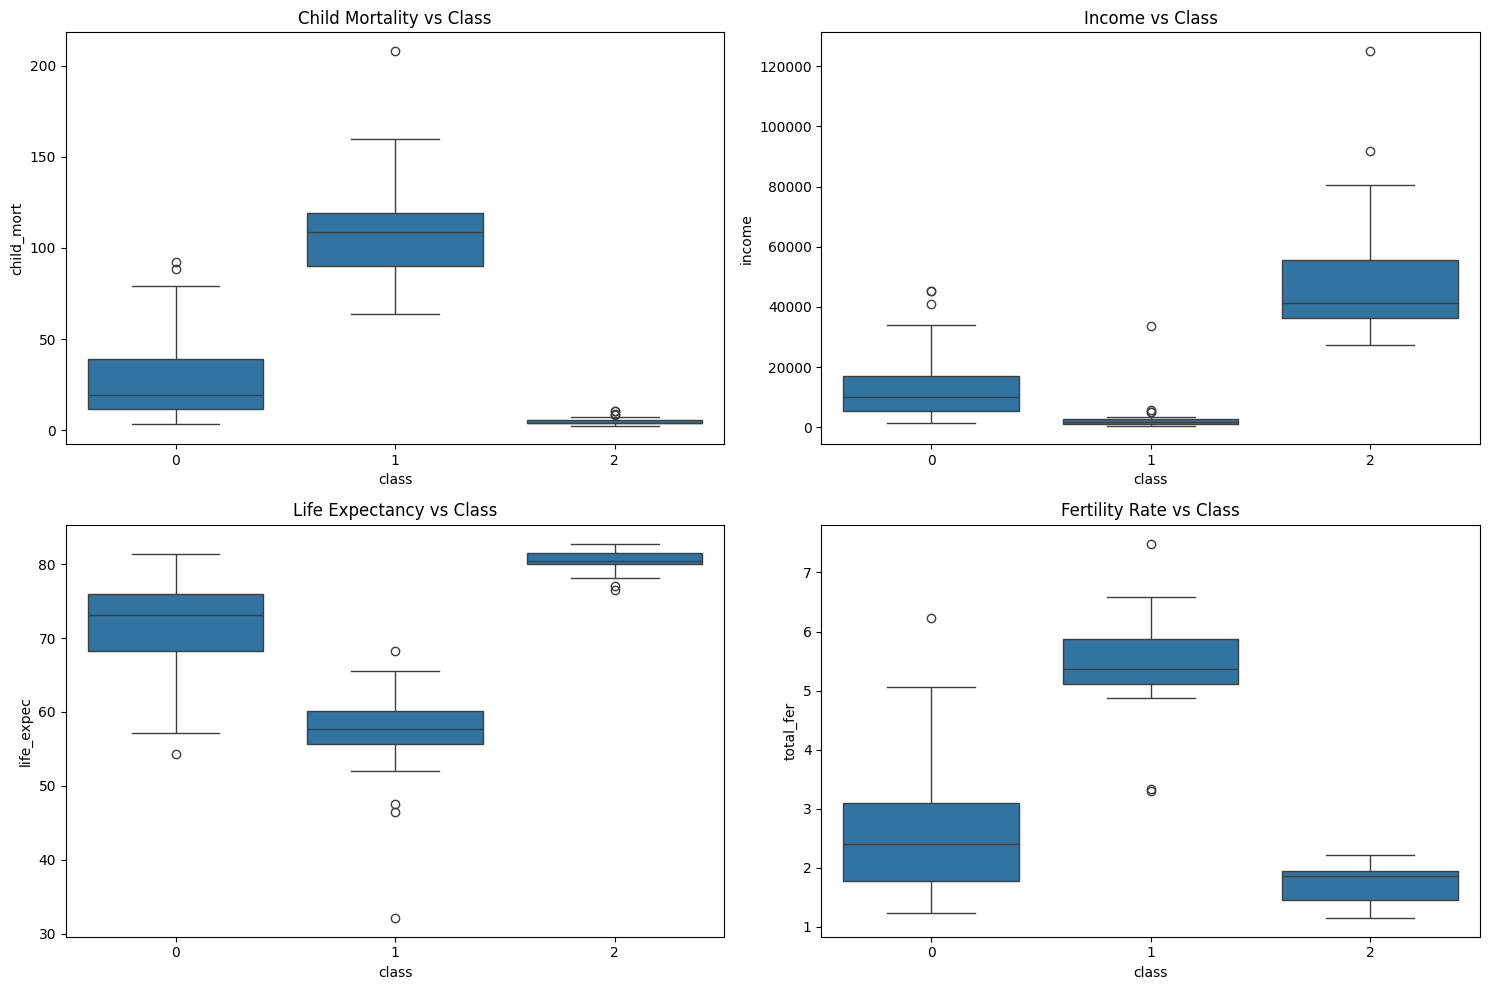

In [171]:
fig, ax = plt.subplots(2, 2, figsize=(15,10))

sns.boxplot(data=df, x="class", y="child_mort", ax=ax[0,0])
ax[0,0].set_title("Child Mortality vs Class")

sns.boxplot(data=df, x="class", y="income", ax=ax[0,1])
ax[0,1].set_title("Income vs Class")

sns.boxplot(data=df, x="class", y="life_expec", ax=ax[1,0])
ax[1,0].set_title("Life Expectancy vs Class")

sns.boxplot(data=df, x="class", y="total_fer", ax=ax[1,1])
ax[1,1].set_title("Fertility Rate vs Class")

plt.tight_layout()
plt.show()



In [172]:
# 2 => no budget needed
# 0 => in between
# 1 => budget needed

In [173]:
import plotly.express as px

In [174]:
pca_df_new.insert(0,column="Country",value=df['country'])

In [175]:
pca_df_new['Class'] = labels

In [176]:
pca_df_new.head()

,Country,0,1,2,cluster,Class
0,Afghanistan,0.599078,0.095490,0.157554,1,1
1,Albania,-0.158474,-0.212092,-0.064189,0,0
2,Algeria,-0.003686,-0.135867,-0.134182,0,0
3,Angola,0.650235,0.275975,-0.142672,1,1
4,Antigua and Barbuda,-0.200711,-0.064662,-0.100715,0,0


In [177]:
pca_df_new.drop("cluster", axis=1, inplace=True)

In [178]:
pca_df_new.head()

,Country,0,1,2,Class
0,Afghanistan,0.599078,0.095490,0.157554,1
1,Albania,-0.158474,-0.212092,-0.064189,0
2,Algeria,-0.003686,-0.135867,-0.134182,0
3,Angola,0.650235,0.275975,-0.142672,1
4,Antigua and Barbuda,-0.200711,-0.064662,-0.100715,0


In [179]:
pca_df_new.loc[pca_df_new['Class'] == 1, 'Class'] = "Budget Needed"
pca_df_new.loc[pca_df_new['Class'] == 0, 'Class'] = "In Between"
pca_df_new.loc[pca_df_new['Class'] == 2, 'Class'] = "No Budget Needed"

/tmp/ipython-input-4196945182.py:1: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Budget Needed' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.



In [180]:
pca_df_new

,Country,0,1,2,Class
0,Afghanistan,0.599078,0.095490,0.157554,Budget Needed
1,Albania,-0.158474,-0.212092,-0.064189,In Between
2,Algeria,-0.003686,-0.135867,-0.134182,In Between
3,Angola,0.650235,0.275975,-0.142672,Budget Needed
4,Antigua and Barbuda,-0.200711,-0.064662,-0.100715,In Between
...,...,...,...,...,...
162,Vanuatu,0.160078,-0.029625,-0.121910,In Between
163,Venezuela,-0.061133,-0.171339,-0.058586,In Between
164,Vietnam,-0.115512,-0.032034,-0.195243,In Between
165,Yemen,0.332968,-0.019824,-0.029989,In Between


In [181]:
fig = px.choropleth(
    pca_df_new[['Country',"Class"]],
    locationmode = "country names",
    locations = "Country",
    title = "Needed Budget By Country",
    color = pca_df_new['Class'],
    color_discrete_map = {
        "Budget Needed" : "Red",
        "In Between" : "Yellow",
        "No Budget Needed" : "Green"
    }
)
fig.update_geos(fitbounds="locations",visible=True)
fig.show()

In [182]:
from sklearn.cluster import DBSCAN

In [183]:
X = df.select_dtypes(include="number").drop(columns=["class"])

In [184]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [185]:
dbscan = DBSCAN(eps=1.2, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

print("Cluster sayısı:", len(set(labels)) - (1 if -1 in labels else 0))
print("Noise sayısı:", list(labels).count(-1))

Cluster sayısı: 3
Noise sayısı: 53


In [186]:
X_pca = pca_df_new.iloc[:, 1:4].values
X_pca_scaled = StandardScaler().fit_transform(X_pca)

dbscan = DBSCAN(eps=0.8, min_samples=5)
labels_pca = dbscan.fit_predict(X_pca_scaled)

print("Cluster sayısı:", len(set(labels_pca)) - (1 if -1 in labels_pca else 0))
print("Noise:", list(labels_pca).count(-1))

Cluster sayısı: 1
Noise: 13


In [187]:
eps_values = [0.1,0.2,0.3,0.4,0.5,0.6]
min_samples_values = [4,5,6]

results = []

for eps in eps_values:
    for min_sample in min_samples_values:

        db = DBSCAN(eps=eps, min_samples=min_sample)
        labels = db.fit_predict(X_pca_scaled)


        mask = labels != -1


        if len(set(labels[mask])) <= 1:
            continue

        silhouette = silhouette_score(X_pca_scaled[mask], labels[mask])

        results.append({
            "eps": eps,
            "min_samples": min_sample,
            "silhouette": silhouette,
            "n_clusters": len(set(labels)) - (1 if -1 in labels else 0),
            "noise": list(labels).count(-1)
        })

results_df = pd.DataFrame(results).sort_values(by="silhouette", ascending=False)
results_df

,eps,min_samples,silhouette,n_clusters,noise
0,0.2,4,0.687919,2,157
3,0.3,6,0.576255,2,145
4,0.4,4,0.481939,4,73
1,0.3,4,0.425189,5,108
8,0.5,5,0.378197,2,49
9,0.5,6,0.359149,2,59
5,0.4,5,0.330580,5,79
2,0.3,5,0.308838,5,124
6,0.4,6,0.281016,5,85
7,0.5,4,0.065765,4,35


DBSCAN parameter tuning revealed that high silhouette scores correspond to configurations where most countries are treated as noise. This indicates that density-based clustering is not suitable for full segmentation but is effective for identifying outlier countries with extreme socio-economic profiles.

In [188]:
import hdbscan

In [189]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=10)
labels_hdb = clusterer.fit_predict(X_scaled)

In [190]:
X_pca = pca_df_new.iloc[:, 1:4].values
X_scaled = StandardScaler().fit_transform(X_pca)

clusterer = hdbscan.HDBSCAN(min_cluster_size=10)
labels_hdb = clusterer.fit_predict(X_scaled)

print("Cluster sayısı:", len(set(labels_hdb)) - (1 if -1 in labels_hdb else 0))
print("Noise sayısı:", list(labels_hdb).count(-1))

Cluster sayısı: 2
Noise sayısı: 47


In [191]:
pca_df_new["hdb_cluster"] = labels_hdb
outliers = pca_df_new.loc[pca_df_new["hdb_cluster"] == -1, "Country"]
print(outliers.tolist())

['Angola', 'Austria', 'Belgium', 'Brazil', 'Brunei', 'Burundi', 'Chad', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Denmark', 'Equatorial Guinea', 'France', 'Greece', 'Guinea-Bissau', 'Haiti', 'Iceland', 'Iraq', 'Ireland', 'Israel', 'Kiribati', 'Kuwait', 'Lesotho', 'Liberia', 'Luxembourg', 'Malaysia', 'Malta', 'Mauritania', 'Micronesia, Fed. Sts.', 'Myanmar', 'Netherlands', 'Niger', 'Norway', 'Qatar', 'Rwanda', 'Seychelles', 'Sierra Leone', 'Singapore', 'Slovenia', 'South Africa', 'Spain', 'Switzerland', 'Thailand', 'Timor-Leste', 'Turkmenistan', 'Uganda', 'United Arab Emirates', 'United States']


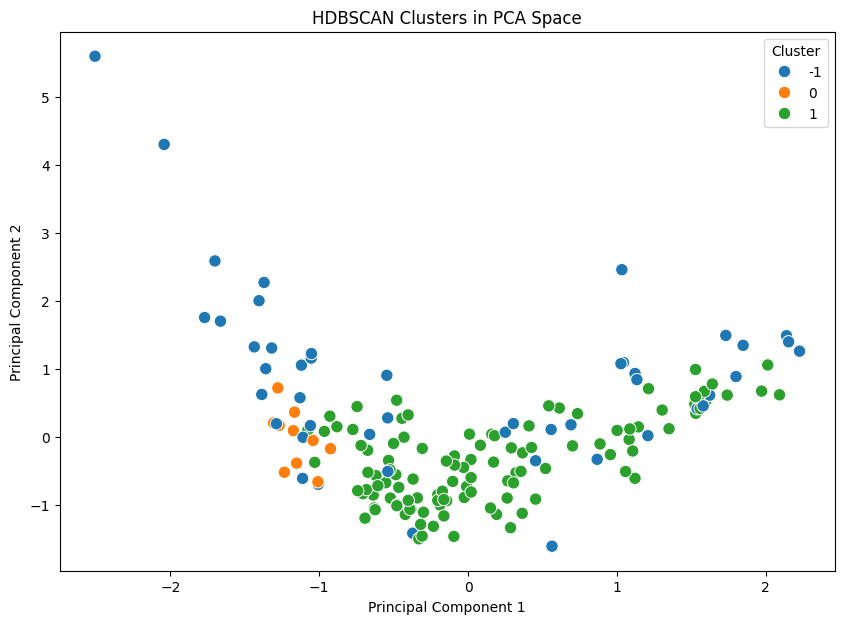

In [192]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x=X_scaled[:,0],
    y=X_scaled[:,1],
    hue=labels_hdb,
    palette="tab10",
    s=80
)

plt.title("HDBSCAN Clusters in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

In [193]:
plot_df = pca_df_new.copy()
plot_df["hdb_cluster"] = labels_hdb

fig = px.scatter(
    plot_df,
    x=0, y=1,
    color="hdb_cluster",
    hover_name="Country",
    title="HDBSCAN Clusters (PCA Space)"
)

fig.show()

In [194]:
fig = px.scatter_3d(
    plot_df,
    x=0, y=1, z=2,
    color="hdb_cluster",
    hover_name="Country",
    title="HDBSCAN 3D Clusters"
)

fig.show()

In [195]:
min_cluster_sizes = [3,5,7,10]
min_samples_list = [None,3,5,7]

results = []

for min_cluster in min_cluster_sizes:
    for min_sample in min_samples_list:

        hdb = hdbscan.HDBSCAN(min_cluster_size=min_cluster, min_samples=min_sample)
        labels = hdb.fit_predict(X_scaled)


        mask = labels != -1


        if len(set(labels[mask])) <= 1:
            continue

        silhouette = silhouette_score(X_scaled[mask], labels[mask])

        results.append({
            "min_cluster_size": min_cluster,
            "min_samples": min_sample,
            "silhouette": silhouette,
            "n_clusters": len(set(labels)) - (1 if -1 in labels else 0),
            "noise": list(labels).count(-1)
        })

results_df = pd.DataFrame(results).sort_values(by="silhouette", ascending=False)
results_df

,min_cluster_size,min_samples,silhouette,n_clusters,noise
11,7,7.0,0.548524,2,100
15,10,7.0,0.548524,2,100
8,7,NaN,0.548524,2,100
3,3,7.0,0.522281,3,94
7,5,7.0,0.522281,3,94
6,5,5.0,0.497836,3,79
4,5,NaN,0.497836,3,79
2,3,5.0,0.497836,3,79
14,10,5.0,0.497836,3,79
10,7,5.0,0.497836,3,79


HDBSCAN identified several dense country groups but also classified a large portion of countries as noise, indicating that global socio-economic development does not form clear density-based clusters. Thus, hierarchical clustering remains more suitable for segmentation, while HDBSCAN effectively highlights extreme country profiles.Density-based clustering revealed that countries do not form clear density-separated groups but instead follow a gradual socio-economic continuum. Therefore, hierarchical clustering provided more meaningful segmentation, while DBSCAN and HDBSCAN were effective in identifying outlier country profiles.

In [196]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,class
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0


In [197]:
# I'm going to try these algorithms without using PCA

In [198]:
X = df.select_dtypes(include="number").drop(columns=["class"])
X_scaled = StandardScaler().fit_transform(X)

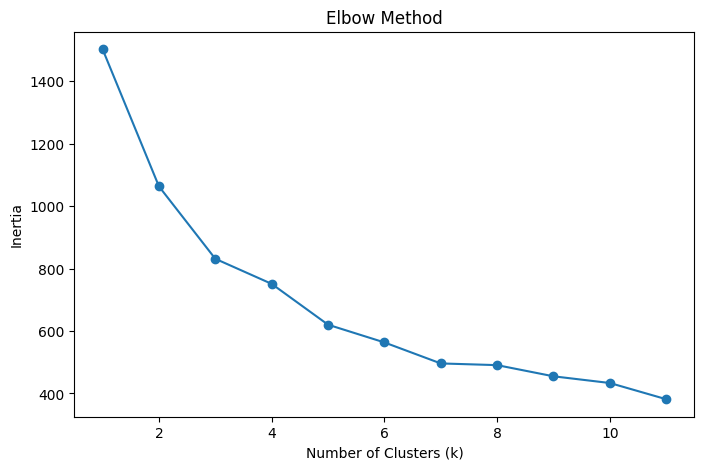

In [199]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1,12):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,12), inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


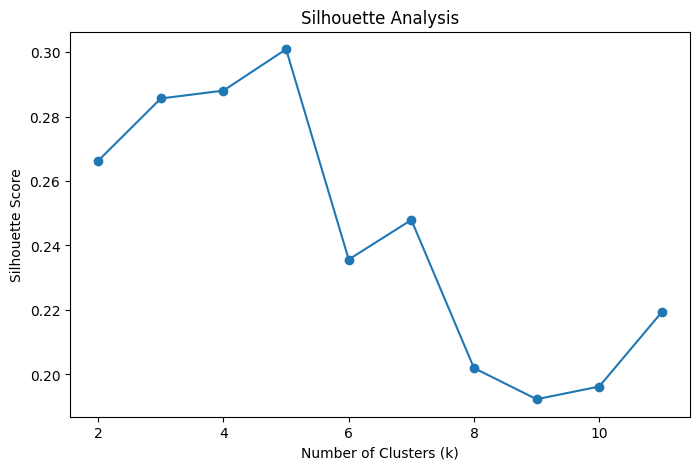

In [200]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2,12):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8,5))
plt.plot(range(2,12), sil_scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

In [201]:
results = []

for k in range(2,12):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    results.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(X_scaled, labels)
    })

import pandas as pd
pd.DataFrame(results)


,k,inertia,silhouette
0,2,1063.482560,0.266296
1,3,831.535158,0.285601
2,4,751.191575,0.288047
3,5,620.362153,0.300882
4,6,563.560286,0.235650
5,7,496.269600,0.247931
6,8,490.800836,0.201982
7,9,455.017022,0.192307
8,10,433.538441,0.196245
9,11,381.594942,0.219351


In [202]:
from sklearn.preprocessing import StandardScaler

X = df.select_dtypes(include="number").drop(columns=["class"])
X_scaled = StandardScaler().fit_transform(X)

In [203]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

db = DBSCAN(eps=1.5, min_samples=5)
labels_db = db.fit_predict(X_scaled)

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
noise_db = list(labels_db).count(-1)

print("DBSCAN clusters:", n_clusters_db)
print("DBSCAN noise:", noise_db)


mask = labels_db != -1
if len(set(labels_db[mask])) > 1:
    print("DBSCAN silhouette:", silhouette_score(X_scaled[mask], labels_db[mask]))

DBSCAN clusters: 1
DBSCAN noise: 30


In [204]:
eps_list = [1.0, 1.2, 1.5, 1.8, 2.0]
min_samples_list = [4,5,6]

results_db = []

for eps in eps_list:
    for ms in min_samples_list:
        labels = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_scaled)
        mask = labels != -1
        if len(set(labels[mask])) <= 1:
            continue
        results_db.append({
            "eps": eps,
            "min_samples": ms,
            "clusters": len(set(labels)) - (1 if -1 in labels else 0),
            "noise": list(labels).count(-1),
            "silhouette": silhouette_score(X_scaled[mask], labels[mask])
        })

import pandas as pd
pd.DataFrame(results_db).sort_values("silhouette", ascending=False)

,eps,min_samples,clusters,noise,silhouette
2,1.0,6,2,113,0.444276
1,1.0,5,3,94,0.434453
5,1.2,6,3,63,0.392005
4,1.2,5,3,53,0.385026
3,1.2,4,3,50,0.369637
0,1.0,4,4,84,0.343844


In [205]:
import hdbscan

hdb = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=None)
labels_hdb = hdb.fit_predict(X_scaled)

n_clusters_hdb = len(set(labels_hdb)) - (1 if -1 in labels_hdb else 0)
noise_hdb = list(labels_hdb).count(-1)

print("HDBSCAN clusters:", n_clusters_hdb)
print("HDBSCAN noise:", noise_hdb)

# Silhouette (noise hariç)
mask = labels_hdb != -1
if len(set(labels_hdb[mask])) > 1:
    print("HDBSCAN silhouette:", silhouette_score(X_scaled[mask], labels_hdb[mask]))


HDBSCAN clusters: 2
HDBSCAN noise: 96
HDBSCAN silhouette: 0.38389261100193267


In [206]:
min_cluster_sizes = [5, 7, 10, 15]
min_samples_list = [None, 5, 7]

results_hdb = []

for mcs in min_cluster_sizes:
    for ms in min_samples_list:
        labels = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=ms).fit_predict(X_scaled)
        mask = labels != -1
        if len(set(labels[mask])) <= 1:
            continue
        results_hdb.append({
            "min_cluster_size": mcs,
            "min_samples": ms,
            "clusters": len(set(labels)) - (1 if -1 in labels else 0),
            "noise": list(labels).count(-1),
            "silhouette": silhouette_score(X_scaled[mask], labels[mask])
        })

pd.DataFrame(results_hdb).sort_values("silhouette", ascending=False)


,min_cluster_size,min_samples,clusters,noise,silhouette
10,15,7.0,2,104,0.469740
3,7,NaN,3,93,0.455252
2,5,7.0,3,93,0.455252
8,10,7.0,3,93,0.455252
5,7,7.0,3,93,0.455252
1,5,5.0,3,72,0.429281
0,5,NaN,3,72,0.429281
7,10,5.0,3,72,0.429281
4,7,5.0,3,72,0.429281
9,15,5.0,3,72,0.429281


Comparison of Clustering with and without PCA

In this study, clustering was performed both on the original standardized feature space and on the PCA-transformed feature space to evaluate the impact of dimensionality reduction on cluster structure.

When clustering was applied without PCA, algorithms operated directly on all socio-economic indicators (income, life expectancy, fertility, etc.). This preserves full information but introduces high-dimensional noise and correlations between variables. As a result, distance-based methods such as KMeans showed moderate separation, while density-based methods (DBSCAN, HDBSCAN) struggled to identify stable clusters and classified many countries as noise. This indicates that the original feature space contains gradual transitions rather than compact, dense clusters.

After applying PCA, the feature space was reduced to principal components that capture the most important variance while removing noise and redundancy. In this reduced space, KMeans achieved a higher silhouette score (≈ 0.44), indicating improved cluster cohesion and separation. PCA helped reveal the underlying structure of the data by emphasizing dominant socio-economic patterns and smoothing out minor variations.

However, PCA also alters the geometry of the data. While it improves distance-based clustering performance, it can distort density relationships, which explains why density-based algorithms did not significantly improve after PCA. Therefore:

Without PCA: Clustering reflects raw socio-economic complexity but suffers from noise and overlapping clusters.

With PCA: Clusters become more compact and interpretable for distance-based methods, revealing clearer development-level groupings.

Overall, PCA enhanced segmentation quality for KMeans and hierarchical clustering, while density-based methods mainly served to identify outlier countries rather than meaningful global segments.